In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
load_dotenv()

True

In [26]:
llm = ChatGoogleGenerativeAI(model = "gemini-3.5-flash-lite",
                                max_tokens = 512,)

In [27]:
class OptimizationState(TypedDict):
    product_name: str
    product_features: List[str]
    target_audience: str
    current_description: str
    evaluation_result: dict
    feedback: str
    iteration_count: int
    max_iterations: int
    is_approved: bool
    iteration_history: List[dict] 

In [28]:
class ProductDescription(BaseModel):
    headline: str = Field(description="Catchy headline (max 10 words)")
    description: str = Field(description="Main product description (100-150 words)")
    key_benefits: List[str] = Field(description= "3-5 key benefits as bullet points")
    call_to_action: str = Field(description="Compelling call-to-action")

In [29]:
class Evaluation(BaseModel):
    overall_score: int = Field(description="Overall quality score 1-10", ge=1, le=10)
    clarity_score: int = Field(description="Clarity score 1-10", ge=1, le=10)
    persuasiveness_score: int = Field(description="Persuasiveness score 1-10", ge=1, le=10)
    audience_fit_score: int = Field(description="Target audience fit 1-10", ge=1, le=10)
    is_approved: bool = Field(description="Whether description meets standards (score >= 8)")
    strengths: List[str] = Field(description="What works well")
    weaknesses: List[str] = Field(description="What needs improvement")
    specific_feedback: str = Field(description="Detailed, actionable feedback for revision")

## Optimizer

In [30]:
def generate_description(state: OptimizationState) -> OptimizationState:
    iteration = state['iteration_count']
    
    print(f"\n{'='*70}")
    print(f"✍️ OPTIMIZER: Iteration {iteration}")
    print(f"{'='*70}")

    optimizer_llm = llm.with_structured_output(ProductDescription)

    if iteration == 1:
        print("Creating initial product description...")

        prompt = f"""Create a compelling product description for:

        Product: {state['product_name']}
        Features: {', '.join(state['product_features'])}
        Target Audience: {state['target_audience']}

        Requirements:
        - Headline: Catchy and concise (max 10 words)
        - Description: Engaging and informative (100-150 words)
        - Key Benefits: 3-5 clear, compelling benefits
        - Call-to-Action: Strong, action-oriented CTA

        Make it persuasive and tailored to the target audience."""

    else:
        print("Refining description based on evaluation feedback...\n")

        prompt = f"""Improve this product description based on feedback:

        Product: {state['product_name']}
        Target Audience: {state['target_audience']}

        CURRENT DESCRIPTION:
        {state['current_description']}

        EVALUATION SCORES:
        - Overall: {state['evaluation_result'].get('overall_score', 0)}/10
        - Clarity: {state['evaluation_result'].get('clarity_score', 0)}/10
        - Persuasiveness: {state['evaluation_result'].get('persuasiveness_score', 0)}/10
        - Audience Fit: {state['evaluation_result'].get('audience_fit_score', 0)}/10

        FEEDBACK TO ADDRESS:
        {state['feedback']}

        CRITICAL: Focus on the specific weaknesses mentioned. Make targeted improvements to:
        1. Address each point in the feedback
        2. Maintain the strengths that were working
        3. Increase scores in weak areas

        Generate an improved version that addresses all feedback."""

    description = optimizer_llm.invoke(prompt)

    formatted_description = f"""
        HEADLINE: {description.headline}

        DESCRIPTION:
        {description.description}

        KEY BENEFITS:

        {chr(10).join([f"* {benefit}" for benefit in description.key_benefits])}

        CALL TO ACTION:
        {description.call_to_action}
    """

    print("Generation Description:")
    print("-"*70)
    print(formatted_description + "\n")

    return {
        "current_description": formatted_description,
        "iteration_count": iteration + 1
    }


## Evaluator

In [31]:
def evaluate_description(state: OptimizationState) -> OptimizationState:

    print(f"\n{'='*70}")
    print(f"🔍 EVALUATOR: Reviewing Description....")
    print(f"{'='*70}")

    evaluator_llm = llm.with_structured_output(Evaluation)

    prompt = f"""Evaluate this product description objectively:

        Product: {state['product_name']}
        Target Audience: {state['target_audience']}

        DESCRIPTION TO EVALUATE:
        {state['current_description']}

        Evaluate on these criteria (1-10 scale):
        1. CLARITY: Is it clear and easy to understand?
        2. PERSUASIVENESS: Does it effectively sell the product?
        3. AUDIENCE FIT: Does it resonate with the target audience?

        APPROVAL CRITERIA: Overall score must be 8 or higher to approve.

        Provide:
        - Scores for each criterion
        - Overall score (average of criteria)
        - Whether it's approved (score >= 8)
        - Specific strengths (what's working well)
        - Specific weaknesses (what needs improvement)
        - Actionable feedback for the next iteration

        Be objective and constructive."""
    
    evaluation = evaluator_llm.invoke(prompt)

    print(f"Evaluation Results")
    print("-" * 70)

    print(f"Overall Score: {evaluation.overall_score}/10")
    print(f"Clarity: {evaluation.clarity_score}/10")
    print(f"Persuasiveness: {evaluation.persuasiveness_score}/10")
    print(f"Audience Fit: {evaluation.audience_fit_score}/10")
    print(f"STATUS: {'✅ APPROVED' if evaluation.is_approved else '❌ NEEDS REVISION'}")
    print(f"\nStrengths:")
    for strength in evaluation.strengths:
        print(f"- {strength}")

    print(f"\nWeaknesses:")
    for weakness in evaluation.weaknesses:
        print(f"- {weakness}")

    print(f"\nFeedback: {evaluation.specific_feedback}")

    iteration_record = {
        "iteration": state["iteration_count"],
        "description": state["current_description"],
        "scores": {
            "overall": evaluation.overall_score,
            "clarity": evaluation.clarity_score,
            "persuasiveness": evaluation.persuasiveness_score,
            "audience_fit": evaluation.audience_fit_score
        },
        "approved": evaluation.is_approved,
        "feedback": evaluation.specific_feedback
    }

    history = state.get("iteration_history", [])
    history.append(iteration_record)

    return {
        "evaluation_result": evaluation.model_dump(),
        "feedback": evaluation.specific_feedback,
        "is_approved": evaluation.is_approved,
        "iteration_history": history
    }

## Decide

In [32]:
def should_continue(state: OptimizationState) -> Literal["optimizer", "end"]:

    if state["is_approved"]:
        print("\n✅ SUCCESS: Description Approved!")

        return "end"
    
    if state["iteration_count"] > state["max_iterations"]:
        print(f"\n⚠️ MAX ITERATIONS REACHED: Stopping at iteration {state['iteration_count'] - 1}")

        return "end"
    
    print(f"\n CONTINUING: Routing back to optimizer for iteration {state['iteration_count']}")

    return "optimizer"

## Graph

In [33]:
builder = StateGraph(OptimizationState)

builder.add_node("optimizer", generate_description)
builder.add_node("evaluator", evaluate_description)

builder.add_edge(START, "optimizer")
builder.add_edge("optimizer", "evaluator")

builder.add_conditional_edges(
    "evaluator",
    should_continue,
    {
        "optimizer": "optimizer",
        "end": END
    }
)

graph = builder.compile()

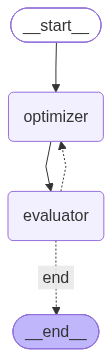

In [34]:
graph

In [35]:
result = graph.invoke({
    "product_name": "Fitpulse Pro Smart watch",
    "product_features": [
        "Heart rate monitoring",
        "GPS tracking",
        "Sleep analysis",
        "Waterproof to 50m",
        "7-day battery life",
        "Smartphone notifications"
    ],
    "target_audience": "Health-concious professionals aged 25-45",
    "current_description": "",
    "evaluation_result": {},
    "feedback": "",
    "iteration_count": 1,
    "max_iterations": 5,
    "is_approved": False,
    "iteration_history": []
})


✍️ OPTIMIZER: Iteration 1
Creating initial product description...
Generation Description:
----------------------------------------------------------------------

        HEADLINE: Elevate Your Health and Productivity with Fitpulse Pro

        DESCRIPTION:
        For busy professionals juggling career and wellness, the Fitpulse Pro Smartwatch is your ultimate daily companion. Designed to seamlessly integrate into your demanding lifestyle, this sleek wearable keeps you connected without missing a beat. Whether you are closing deals in the boardroom or crushing personal fitness goals, Fitpulse Pro empowers you to take control of your health. With advanced biometric tracking, you can monitor your heart rate, analyze your sleep patterns, and map your runs with precision GPS. Never worry about constantly recharging your device, thanks to an impressive seven-day battery life, and stay effortlessly connected with smart notifications right on your wrist. Built to withstand your active lifest